In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/clean_meal_data.csv"
)

df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(10944, 25)


,date,mess_name,meal_type,menu_name,hostel_occupancy_pct,exam_day,holiday,special_event,temperature_c,rainfall_mm,...,food_wasted_kg,food_cost_per_kg,day_of_week,day_of_week_num,month,is_weekend,semester,portion_kg,planned_preparation_kg,waste_rate
0,2025-01-01,Academic Block Mess,Breakfast,Sandwich,85.62,0,0,0,28.81,0.08,...,18.22,90,Wednesday,2,1,0,4,0.30,109.512,0.168035
1,2025-01-01,Academic Block Mess,Dinner,Khichdi,85.62,0,0,0,28.81,0.08,...,45.83,105,Wednesday,2,1,0,4,0.40,245.376,0.180015
2,2025-01-01,Academic Block Mess,Lunch,Biryani,85.62,0,0,0,28.81,0.08,...,61.49,110,Wednesday,2,1,0,4,0.45,349.434,0.180095
3,2025-01-01,Central Mess,Breakfast,Poha,80.52,0,0,0,28.81,0.08,...,29.65,90,Wednesday,2,1,0,4,0.30,156.816,0.194095
4,2025-01-01,Central Mess,Dinner,Pasta,80.52,0,0,0,28.81,0.08,...,62.66,105,Wednesday,2,1,0,4,0.40,339.120,0.184040


In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10944 entries, 0 to 10943
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    10944 non-null  datetime64[us]
 1   mess_name               10944 non-null  str           
 2   meal_type               10944 non-null  str           
 3   menu_name               10944 non-null  str           
 4   hostel_occupancy_pct    10944 non-null  float64       
 5   exam_day                10944 non-null  int64         
 6   holiday                 10944 non-null  int64         
 7   special_event           10944 non-null  int64         
 8   temperature_c           10944 non-null  float64       
 9   rainfall_mm             10944 non-null  float64       
 10  humidity_pct            10944 non-null  float64       
 11  students_expected       10944 non-null  int64         
 12  students_present        10944 non-null  int64         
 1

In [3]:
df.isnull().sum()

date                      0
mess_name                 0
meal_type                 0
menu_name                 0
hostel_occupancy_pct      0
exam_day                  0
holiday                   0
special_event             0
temperature_c             0
rainfall_mm               0
humidity_pct              0
students_expected         0
students_present          0
food_prepared_kg          0
food_consumed_kg          0
food_wasted_kg            0
food_cost_per_kg          0
day_of_week               0
day_of_week_num           0
month                     0
is_weekend                0
semester                  0
portion_kg                0
planned_preparation_kg    0
waste_rate                0
dtype: int64

In [4]:
df.describe()

,date,hostel_occupancy_pct,exam_day,holiday,special_event,temperature_c,rainfall_mm,humidity_pct,students_expected,students_present,...,food_consumed_kg,food_wasted_kg,food_cost_per_kg,day_of_week_num,month,is_weekend,semester,portion_kg,planned_preparation_kg,waste_rate
count,10944,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,...,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000,10944.000000
mean,2025-10-31 12:00:00,81.488013,0.054276,0.054276,0.023026,27.937451,1.627796,62.265806,589.377741,556.793220,...,212.446991,45.449378,101.666667,3.003289,5.726974,0.286184,3.754934,0.383333,254.299663,0.175575
min,2025-01-01 00:00:00,51.120000,0.000000,0.000000,0.000000,16.620000,0.000000,47.270000,116.000000,111.000000,...,31.660000,3.850000,90.000000,0.000000,1.000000,0.000000,0.000000,0.300000,37.584000,0.069277
25%,2025-06-01 18:00:00,77.690000,0.000000,0.000000,0.000000,23.670000,0.000000,58.160000,418.000000,394.000000,...,117.052500,25.340000,90.000000,1.000000,3.000000,0.000000,4.000000,0.300000,139.968000,0.150869
50%,2025-10-31 12:00:00,82.190000,0.000000,0.000000,0.000000,28.590000,0.000000,61.140000,590.000000,558.000000,...,218.975000,43.315000,105.000000,3.000000,6.000000,0.000000,4.000000,0.400000,262.656000,0.176439
75%,2026-04-01 06:00:00,86.030000,0.000000,0.000000,0.000000,32.250000,1.505000,65.250000,744.000000,702.000000,...,286.510000,61.392500,110.000000,5.000000,8.000000,1.000000,5.000000,0.450000,343.116000,0.200583
max,2026-08-31 00:00:00,98.000000,1.000000,1.000000,1.000000,37.550000,31.970000,98.000000,1190.000000,1131.000000,...,484.930000,136.170000,110.000000,6.000000,12.000000,1.000000,5.000000,0.450000,578.340000,0.267586
std,NaN,7.068337,0.226572,0.226572,0.149994,5.011102,3.717597,6.980743,199.809337,189.265048,...,95.875210,23.196785,8.498754,2.000089,3.194167,0.451997,1.639678,0.062364,114.518454,0.034926


In [5]:
meal_demand = (
    df.groupby("meal_type")["students_present"]
    .mean()
    .sort_values(ascending=False)
)

print(meal_demand)

meal_type
Lunch        707.311404
Dinner       601.059759
Breakfast    362.008498
Name: students_present, dtype: float64


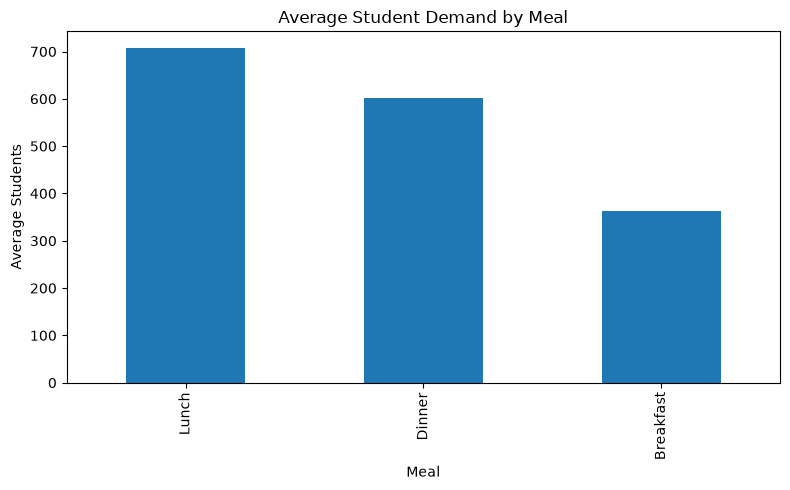

In [6]:
meal_demand.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Student Demand by Meal")
plt.xlabel("Meal")
plt.ylabel("Average Students")
plt.tight_layout()
plt.show()

In [7]:
meal_waste = (
    df.groupby("meal_type")["food_wasted_kg"]
    .mean()
    .sort_values(ascending=False)
)

print(meal_waste)

meal_type
Lunch        65.310400
Dinner       48.888300
Breakfast    22.149433
Name: food_wasted_kg, dtype: float64


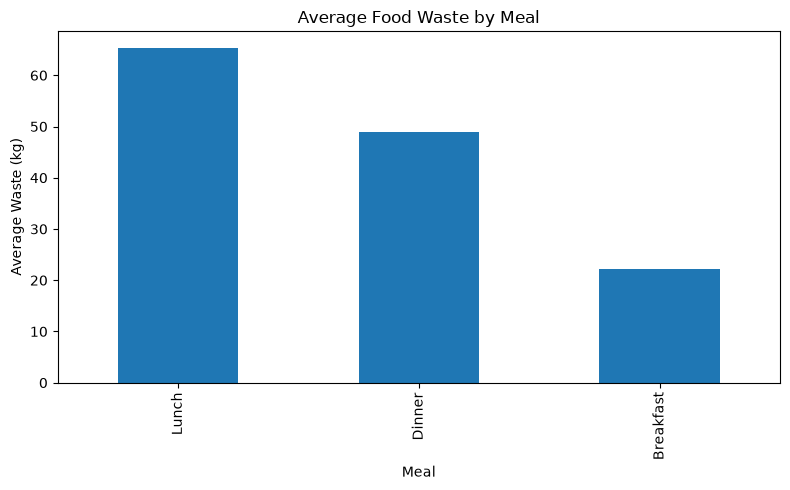

In [8]:
meal_waste.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Food Waste by Meal")
plt.xlabel("Meal")
plt.ylabel("Average Waste (kg)")
plt.tight_layout()
plt.show()

In [9]:
menu_waste = (
    df.groupby("menu_name")["food_wasted_kg"]
    .mean()
    .sort_values(ascending=False)
)

print(menu_waste)

menu_name
Biryani          69.771651
Paneer_Roti      67.571394
Rajma_Rice       65.927163
Rice_Dal         61.844345
Veg_Pulao        61.033196
Chole_Bhature    53.666270
Roti_Dal         50.526404
Fried_Rice       47.391282
Pasta            47.273854
Khichdi          45.616990
Paratha          24.329675
Idli_Dosa        23.088300
Poha             22.010477
Sandwich         20.949612
Upma             20.525643
Name: food_wasted_kg, dtype: float64


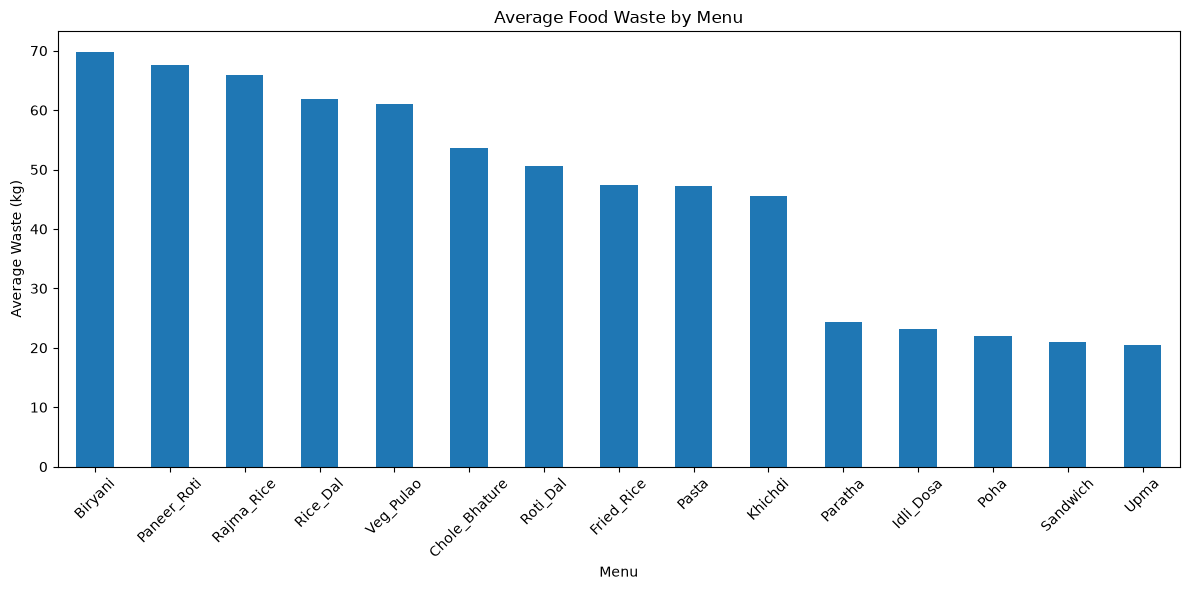

In [10]:
menu_waste.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Food Waste by Menu")
plt.xlabel("Menu")
plt.ylabel("Average Waste (kg)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

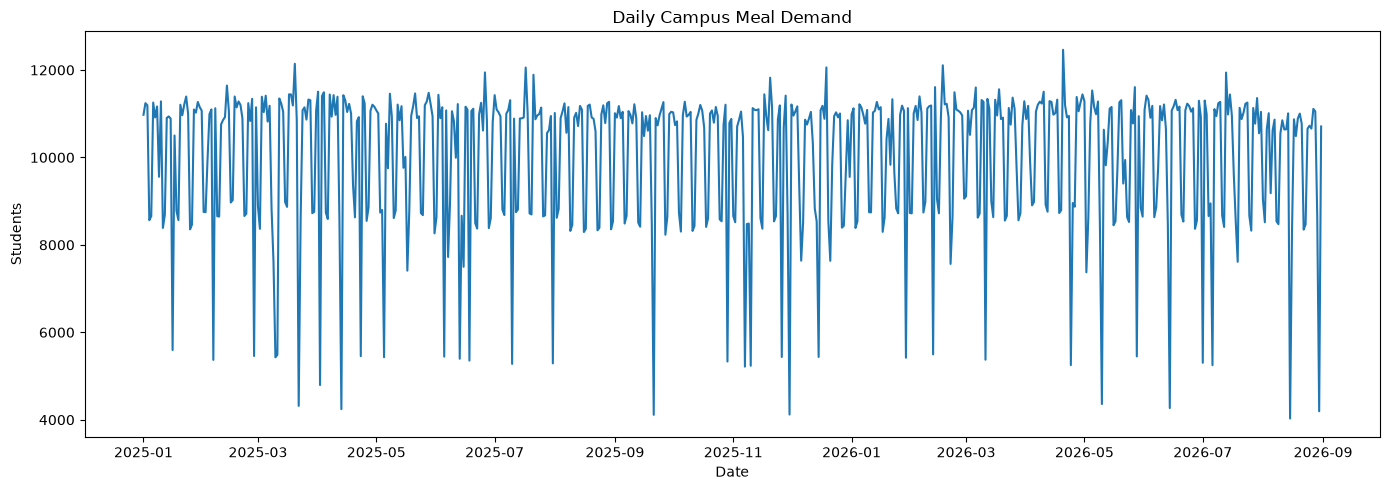

In [11]:
daily_demand = (
    df.groupby("date")["students_present"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand.index,
    daily_demand.values
)

plt.title("Daily Campus Meal Demand")
plt.xlabel("Date")
plt.ylabel("Students")

plt.tight_layout()
plt.show()

In [12]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_demand = (
    df.groupby("day_of_week")["students_present"]
    .mean()
    .reindex(day_order)
)

print(day_demand)

day_of_week
Monday       593.010856
Tuesday      609.180879
Wednesday    585.181354
Thursday     581.876756
Friday       598.281609
Saturday     470.405492
Sunday       460.217752
Name: students_present, dtype: float64


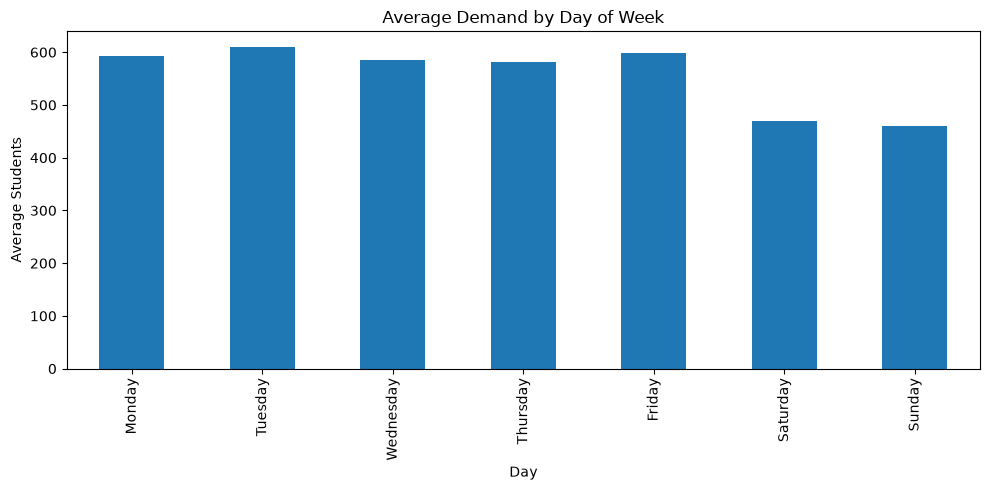

In [13]:
day_demand.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Students")

plt.tight_layout()
plt.show()

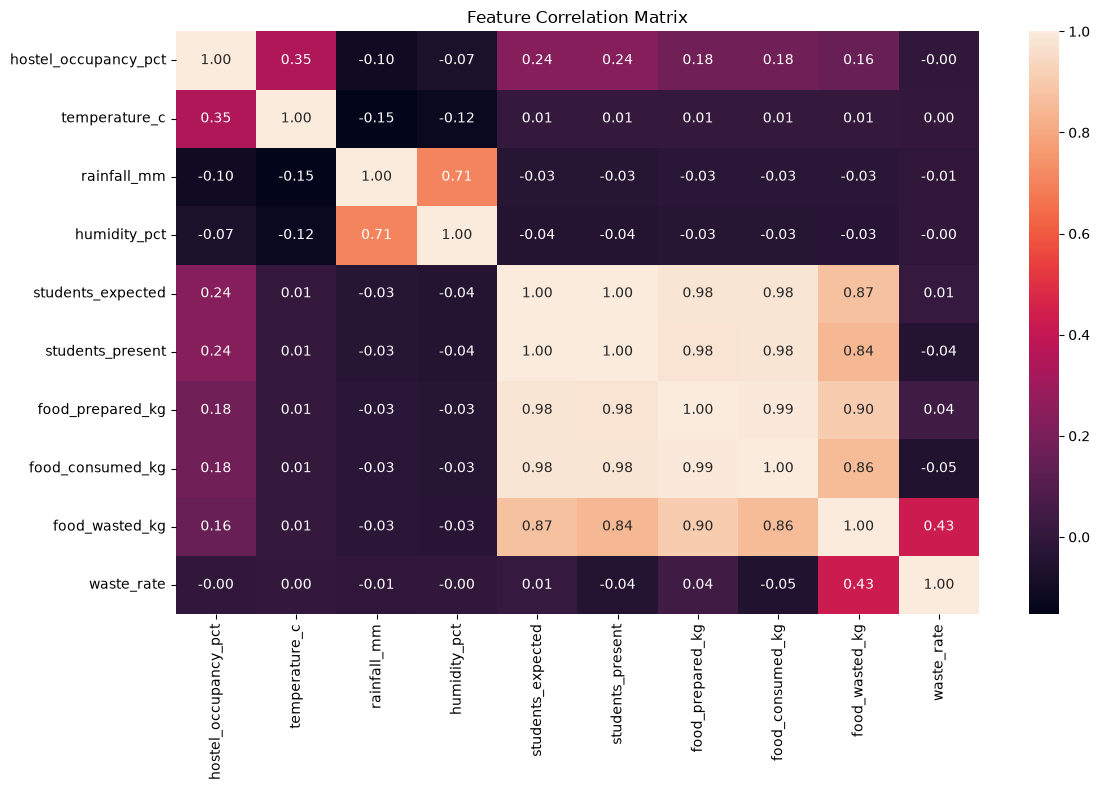

In [14]:
numeric_cols = [
    "hostel_occupancy_pct",
    "temperature_c",
    "rainfall_mm",
    "humidity_pct",
    "students_expected",
    "students_present",
    "food_prepared_kg",
    "food_consumed_kg",
    "food_wasted_kg",
    "waste_rate"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()